## Descarga de dataset y preprocesamiento

In [1]:
import pandas as pd
from sklearn.preprocessing import MultiLabelBinarizer

In [2]:
import kagglehub
path = kagglehub.dataset_download("nih-chest-xrays/sample")

Using Colab cache for faster access to the 'sample' dataset.


In [3]:
data = pd.read_csv(f"{path}/sample_labels.csv")
data.head()

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImageWidth,OriginalImageHeight,OriginalImagePixelSpacing_x,OriginalImagePixelSpacing_y
0,00000013_005.png,Emphysema|Infiltration|Pleural_Thickening|Pneu...,5,13,060Y,M,AP,3056,2544,0.139,0.139
1,00000013_026.png,Cardiomegaly|Emphysema,26,13,057Y,M,AP,2500,2048,0.168,0.168
2,00000017_001.png,No Finding,1,17,077Y,M,AP,2500,2048,0.168,0.168
3,00000030_001.png,Atelectasis,1,30,079Y,M,PA,2992,2991,0.143,0.143
4,00000032_001.png,Cardiomegaly|Edema|Effusion,1,32,055Y,F,AP,2500,2048,0.168,0.168


In [4]:
def parse_age(age_str):
    if 'Y' in age_str:
        return int(age_str.replace('Y', ''))
    elif 'M' in age_str:
        return int(age_str.replace('M', '')) / 12
    elif 'D' in age_str:
        return int(age_str.replace('D', '')) / 365
    else:
        print(f"Formato de edad desconocido: {age_str}")
        return None

data['Age'] = data['Patient Age'].apply(parse_age)
data = data.drop('Patient Age', axis=1)
data.head()

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Gender,View Position,OriginalImageWidth,OriginalImageHeight,OriginalImagePixelSpacing_x,OriginalImagePixelSpacing_y,Age
0,00000013_005.png,Emphysema|Infiltration|Pleural_Thickening|Pneu...,5,13,M,AP,3056,2544,0.139,0.139,60.0
1,00000013_026.png,Cardiomegaly|Emphysema,26,13,M,AP,2500,2048,0.168,0.168,57.0
2,00000017_001.png,No Finding,1,17,M,AP,2500,2048,0.168,0.168,77.0
3,00000030_001.png,Atelectasis,1,30,M,PA,2992,2991,0.143,0.143,79.0
4,00000032_001.png,Cardiomegaly|Edema|Effusion,1,32,F,AP,2500,2048,0.168,0.168,55.0


In [5]:
data = data.drop(["Follow-up #", "Patient ID", "OriginalImageWidth", "OriginalImageHeight", "OriginalImagePixelSpacing_x", "OriginalImagePixelSpacing_y"], axis=1)
data.head()

,Image Index,Finding Labels,Patient Gender,View Position,Age
0,00000013_005.png,Emphysema|Infiltration|Pleural_Thickening|Pneu...,M,AP,60.0
1,00000013_026.png,Cardiomegaly|Emphysema,M,AP,57.0
2,00000017_001.png,No Finding,M,AP,77.0
3,00000030_001.png,Atelectasis,M,PA,79.0
4,00000032_001.png,Cardiomegaly|Edema|Effusion,F,AP,55.0


In [6]:
data = data[data['Age'] < 100]

In [7]:
data["Finding Labels"] = data["Finding Labels"].str.split('|')

mlb = MultiLabelBinarizer()
labels_df = pd.DataFrame(
    mlb.fit_transform(data["Finding Labels"]),
    columns=mlb.classes_,
    index=data.index
)

data = pd.concat([data, labels_df], axis=1)

In [8]:
data.drop("Finding Labels", axis=1, inplace=True)

In [9]:
print(data.head())

        Image Index Patient Gender View Position   Age  Atelectasis  \
0  00000013_005.png              M            AP  60.0            0   
1  00000013_026.png              M            AP  57.0            0   
2  00000017_001.png              M            AP  77.0            0   
3  00000030_001.png              M            PA  79.0            1   
4  00000032_001.png              F            AP  55.0            0   

   Cardiomegaly  Consolidation  Edema  Effusion  Emphysema  Fibrosis  Hernia  \
0             0              0      0         0          1         0       0   
1             1              0      0         0          1         0       0   
2             0              0      0         0          0         0       0   
3             0              0      0         0          0         0       0   
4             1              0      1         1          0         0       0   

   Infiltration  Mass  No Finding  Nodule  Pleural_Thickening  Pneumonia  \
0             1 

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

data['Patient Gender'] = data['Patient Gender'].apply(lambda x: 1 if x == 'M' else 0)
data['View Position'] = data['View Position'].apply(lambda x: 1 if x == 'PA' else 0)

scaler = StandardScaler()
data['Age'] = scaler.fit_transform(data['Age'].values.reshape(-1, 1))

# 3. Crear la columna objetivo para la Cabeza 1 (Normal/Anormal)
# Si 'No Finding' es True, entonces el paciente es 'Normal' (0)
# Si 'No Finding' es False, entonces tiene una patología, es 'Anormal' (1)
data['Anormal'] = (data['No Finding'] == False).astype(int)
data.drop('No Finding', axis=1, inplace=True)
data.head()

,Image Index,Patient Gender,View Position,Age,Atelectasis,Cardiomegaly,Consolidation,Edema,Effusion,Emphysema,Fibrosis,Hernia,Infiltration,Mass,Nodule,Pleural_Thickening,Pneumonia,Pneumothorax,Anormal
0,00000013_005.png,1,0,0.795327,0,0,0,0,0,1,0,0,1,0,0,1,0,1,1
1,00000013_026.png,1,0,0.615893,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1
2,00000017_001.png,1,0,1.812124,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,00000030_001.png,1,1,1.931747,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1
4,00000032_001.png,0,0,0.496270,0,1,0,1,1,0,0,0,0,0,0,0,0,0,1


## Finetuning modelos base

In [11]:
!pip install -q keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 4.8 MB/s eta 0:00:00


In [16]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.applications import ResNet50, DenseNet121
import keras_tuner as kt
import matplotlib.pyplot as plt

In [17]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f"GPU Available: {len(gpus)}")

else:
    print("Usando CPU")

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

# Constantes
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
IMG_DIR = f"{path}/sample/images"

LABEL_COLS = [
    "Atelectasis", "Cardiomegaly", "Consolidation", "Edema", "Effusion",
    "Emphysema", "Fibrosis", "Hernia", "Infiltration", "Mass",
    "Nodule", "Pleural_Thickening", "Pneumonia", "Pneumothorax"
]
NUM_CLASSES = len(LABEL_COLS)

print(f"Clasificando {NUM_CLASSES} etiquetas: {LABEL_COLS}")

GPU Available: 1
Clasificando 14 etiquetas: ['Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion', 'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass', 'Nodule', 'Pleural_Thickening', 'Pneumonia', 'Pneumothorax']


In [18]:
train_df = data.sample(frac=0.8, random_state=42)
val_df = data.drop(train_df.index)

print(f"Train: {len(train_df)} | Val: {len(val_df)}")

Train: 4484 | Val: 1121


In [19]:
class DataGenerator(keras.utils.Sequence):

    def __init__(self, df, img_dir, label_cols, batch_size=32, img_size=(224, 224), is_training=True):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.label_cols = label_cols
        self.batch_size = batch_size
        self.img_size = img_size
        self.is_training = is_training
        self.indexes = np.arange(len(self.df))

        self.augmentor = ImageDataGenerator(
            rotation_range=10,
            zoom_range=[0.9, 1.1],
            width_shift_range=0.1,
            height_shift_range=0.1,
            shear_range=0.05,
            brightness_range=[0.9, 1.1],
            horizontal_flip=False,
            fill_mode='constant',
            cval=0
        )

        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.df) / self.batch_size))

    def on_epoch_end(self):
        if self.is_training:
            np.random.shuffle(self.indexes)

    def __getitem__(self, index):
        # 1. Obtener índices del batch actual
        indexes = self.indexes[index*self.batch_size:(index+1)*self.batch_size]
        batch_df = self.df.iloc[indexes]

        # 2. Inicializar arrays
        X = np.zeros((len(batch_df), *self.img_size, 3), dtype=np.float32)
        y = batch_df[self.label_cols].values.astype(np.float32)

        # 3. Cargar imágenes
        for i, (_, row) in enumerate(batch_df.iterrows()):
            path = os.path.join(self.img_dir, row['Image Index'])
            try:
                img = load_img(path, target_size=self.img_size, color_mode='rgb')
                img_arr = img_to_array(img)

                if self.is_training:
                    params = self.augmentor.get_random_transform(img_arr.shape)
                    img_arr = self.augmentor.apply_transform(img_arr, params)

                X[i] = img_arr
            except Exception as e:
                print(f"Error loading {path}: {e}")

        return X, y

train_gen = DataGenerator(train_df, IMG_DIR, LABEL_COLS, BATCH_SIZE, IMG_SIZE, is_training=True)
val_gen = DataGenerator(val_df, IMG_DIR, LABEL_COLS, BATCH_SIZE, IMG_SIZE, is_training=False)

In [20]:
def build_model(hp):
    model_type = hp.Choice('model_type', ['DenseNet121', 'ResNet50'])
    drop_rate = hp.Float('dropout_rate', 0.2, 0.5, step=0.1)
    units = hp.Int('dense_units', min_value=256, max_value=512, step=128)
    lr = hp.Float('learning_rate', min_value=1e-5, max_value=1e-3, sampling='log')
    wd = hp.Choice('weight_decay', [1e-5, 1e-4])

    inputs = layers.Input(shape=(*IMG_SIZE, 3))

    if model_type == 'DenseNet121':
        x = layers.Lambda(tf.keras.applications.densenet.preprocess_input)(inputs)
        base_model = DenseNet121(include_top=False, weights='imagenet', input_tensor=x)
    else:
        x = layers.Lambda(tf.keras.applications.resnet50.preprocess_input)(inputs)
        base_model = ResNet50(include_top=False, weights='imagenet', input_tensor=x)

    base_model.trainable = False

    x = base_model.output

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(drop_rate)(x)

    x = layers.Dense(units, activation='relu')(x)
    x = layers.Dropout(drop_rate)(x)

    outputs = layers.Dense(NUM_CLASSES, activation='sigmoid')(x)

    model = keras.Model(inputs, outputs)

    model.compile(
        optimizer=keras.optimizers.AdamW(learning_rate=lr, weight_decay=wd),
        loss='binary_crossentropy',
        metrics=[
            tf.keras.metrics.AUC(curve='PR', name='pr_auc'),
            tf.keras.metrics.AUC(name='auc'),
            tf.keras.metrics.Recall(name='recall'),
            'accuracy',
        ]
    )
    return model

In [21]:
tuner = kt.BayesianOptimization(
    build_model,
    objective=kt.Objective("val_pr_auc", direction="max"),
    max_trials=15,
    executions_per_trial=1,
    directory='tuner_results',
    project_name='chest_xray_multilabel',
    overwrite=True
)

stop_early = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

print("Starting optimized search...")
tuner.search(
    train_gen,
    validation_data=val_gen,
    epochs=7,
    callbacks=[stop_early]
)

Trial 13 Complete [00h 18m 07s]
val_pr_auc: 0.2069792002439499

Best val_pr_auc So Far: 0.22965337336063385
Total elapsed time: 03h 45m 13s

Search: Running Trial #14

Value             |Best Value So Far |Hyperparameter
DenseNet121       |ResNet50          |model_type
0.3               |0.3               |dropout_rate
384               |512               |dense_units
0.00035015        |0.000117          |learning_rate
1e-05             |1e-05             |weight_decay

Epoch 1/7
141/141 ━━━━━━━━━━━━━━━━━━━━ 211s 1s/step - accuracy: 0.1355 - auc: 0.6189 - loss: 0.3093 - pr_auc: 0.0688 - recall: 0.0802 - val_accuracy: 0.1427 - val_auc: 0.7605 - val_loss: 0.1803 - val_pr_auc: 0.1909 - val_recall: 0.0000e+00
Epoch 2/7
141/141 ━━━━━━━━━━━━━━━━━━━━ 148s 1s/step - accuracy: 0.1583 - auc: 0.7082 - loss: 0.1947 - pr_auc: 0.1205 - recall: 0.0131 - val_accuracy: 0.1356 - val_auc: 0.7735 - val_loss: 0.1763 - val_pr_auc: 0.1969 - val_recall: 0.0000e+00
Epoch 3/7
141/141 ━━━━━━━━━━━━━━━━━━━━ 151s 1

KeyboardInterrupt: 

### Resultados

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

all_trials = tuner.oracle.get_best_trials(num_trials=len(tuner.oracle.trials))

summary_data = []
for trial in all_trials:
    row = trial.hyperparameters.values.copy()
    row['score (val_pr_auc)'] = trial.score
    row['trial_id'] = trial.trial_id
    summary_data.append(row)

df_summary = pd.DataFrame(summary_data)

cols = ['trial_id', 'score (val_pr_auc)', 'model_type', 'learning_rate', 'dense_units', 'dropout_rate', 'weight_decay']
df_summary = df_summary[cols]

print("--- RESUMEN DE HIPERPARÁMETROS Y PUNTAJES ---")
display(df_summary.style.background_gradient(subset=['score (val_pr_auc)'], cmap='Greens'))

--- RESUMEN DE HIPERPARÁMETROS Y PUNTAJES ---


,trial_id,score (val_pr_auc),model_type,learning_rate,dense_units,dropout_rate,weight_decay
0,03,0.229653,ResNet50,0.000117,512,0.300000,0.000010
1,10,0.218857,ResNet50,0.000315,384,0.300000,0.000100
2,02,0.210982,DenseNet121,0.000686,256,0.300000,0.000010
3,04,0.209828,DenseNet121,0.000580,256,0.400000,0.000010
4,12,0.206979,DenseNet121,0.000157,256,0.200000,0.000010
5,06,0.206911,DenseNet121,0.000143,512,0.200000,0.000010
6,11,0.206762,ResNet50,0.000086,256,0.300000,0.000100
7,07,0.206498,DenseNet121,0.000398,384,0.400000,0.000010
8,08,0.204516,DenseNet121,0.000126,256,0.200000,0.000010
9,00,0.195604,DenseNet121,0.000070,512,0.400000,0.000100


In [30]:
print("\n--- MEJORES HYPERPARAMETROS ---")
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print(f"Model: {best_hps.get('model_type')}")
print(f"Learning Rate: {best_hps.get('learning_rate')}")
print(f"Dropout: {best_hps.get('dropout_rate')}")
print(f"Dense Units: {best_hps.get('dense_units')}")
print(f"Weight Decay: {best_hps.get('weight_decay')}")


--- MEJORES HYPERPARAMETROS ---
Model: ResNet50
Learning Rate: 0.00011699898271783844
Dropout: 0.30000000000000004
Dense Units: 512
Weight Decay: 1e-05


## Modelo final

In [31]:
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print("--- Iniciando entrenamiento del mejor modelo ---")
print(f"Modelo Base: {best_hps.get('model_type')}")
print(f"Learning Rate: {best_hps.get('learning_rate'):.5f}")
print(f"Dense Units: {best_hps.get('dense_units')}")
print(f"Dropout: {best_hps.get('dropout_rate')}")
print(f"Weight Decay: {best_hps.get('weight_decay')}")

best_model = tuner.hypermodel.build(best_hps)

fine_tune_at = int(len(best_model.layers) * 0.95)
for layer in best_model.layers[fine_tune_at:]:
    layer.trainable = True

best_model.compile(
    optimizer=keras.optimizers.AdamW(
        learning_rate=best_hps.get('learning_rate'),
        weight_decay=best_hps.get('weight_decay')
    ),
    loss='binary_crossentropy',
    metrics=[
        tf.keras.metrics.AUC(curve='PR', multi_label=True, num_labels=NUM_CLASSES, name='pr_auc'),
        tf.keras.metrics.AUC(curve='ROC', multi_label=True, num_labels=NUM_CLASSES, name='auc'),
        tf.keras.metrics.Recall(name='recall'),
    ]
)

stop_early_final = tf.keras.callbacks.EarlyStopping(
    monitor='val_pr_auc',
    mode='max',
    patience=3,
    restore_best_weights=True
)

history_best = best_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=15,
    callbacks=[stop_early_final]
)

--- Iniciando entrenamiento del mejor modelo ---
Modelo Base: ResNet50
Learning Rate: 0.00012
Dense Units: 512
Dropout: 0.30000000000000004
Weight Decay: 1e-05
Epoch 1/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 188s 1s/step - auc: 0.5229 - loss: 0.2637 - pr_auc: 0.0556 - recall: 0.0642 - val_auc: 0.6577 - val_loss: 0.1801 - val_pr_auc: 0.0903 - val_recall: 0.0025
Epoch 2/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 158s 1s/step - auc: 0.5865 - loss: 0.1844 - pr_auc: 0.0773 - recall: 0.0262 - val_auc: 0.6850 - val_loss: 0.1756 - val_pr_auc: 0.1052 - val_recall: 0.0037
Epoch 3/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 156s 1s/step - auc: 0.6137 - loss: 0.1816 - pr_auc: 0.0866 - recall: 0.0213 - val_auc: 0.6984 - val_loss: 0.1771 - val_pr_auc: 0.1136 - val_recall: 0.0037
Epoch 4/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 197s 1s/step - auc: 0.6590 - loss: 0.1761 - pr_auc: 0.1051 - recall: 0.0200 - val_auc: 0.7054 - val_loss: 0.1726 - val_pr_auc: 0.1179 - val_recall: 0.0050
Epoch 5/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 172s 1s/step - auc: 

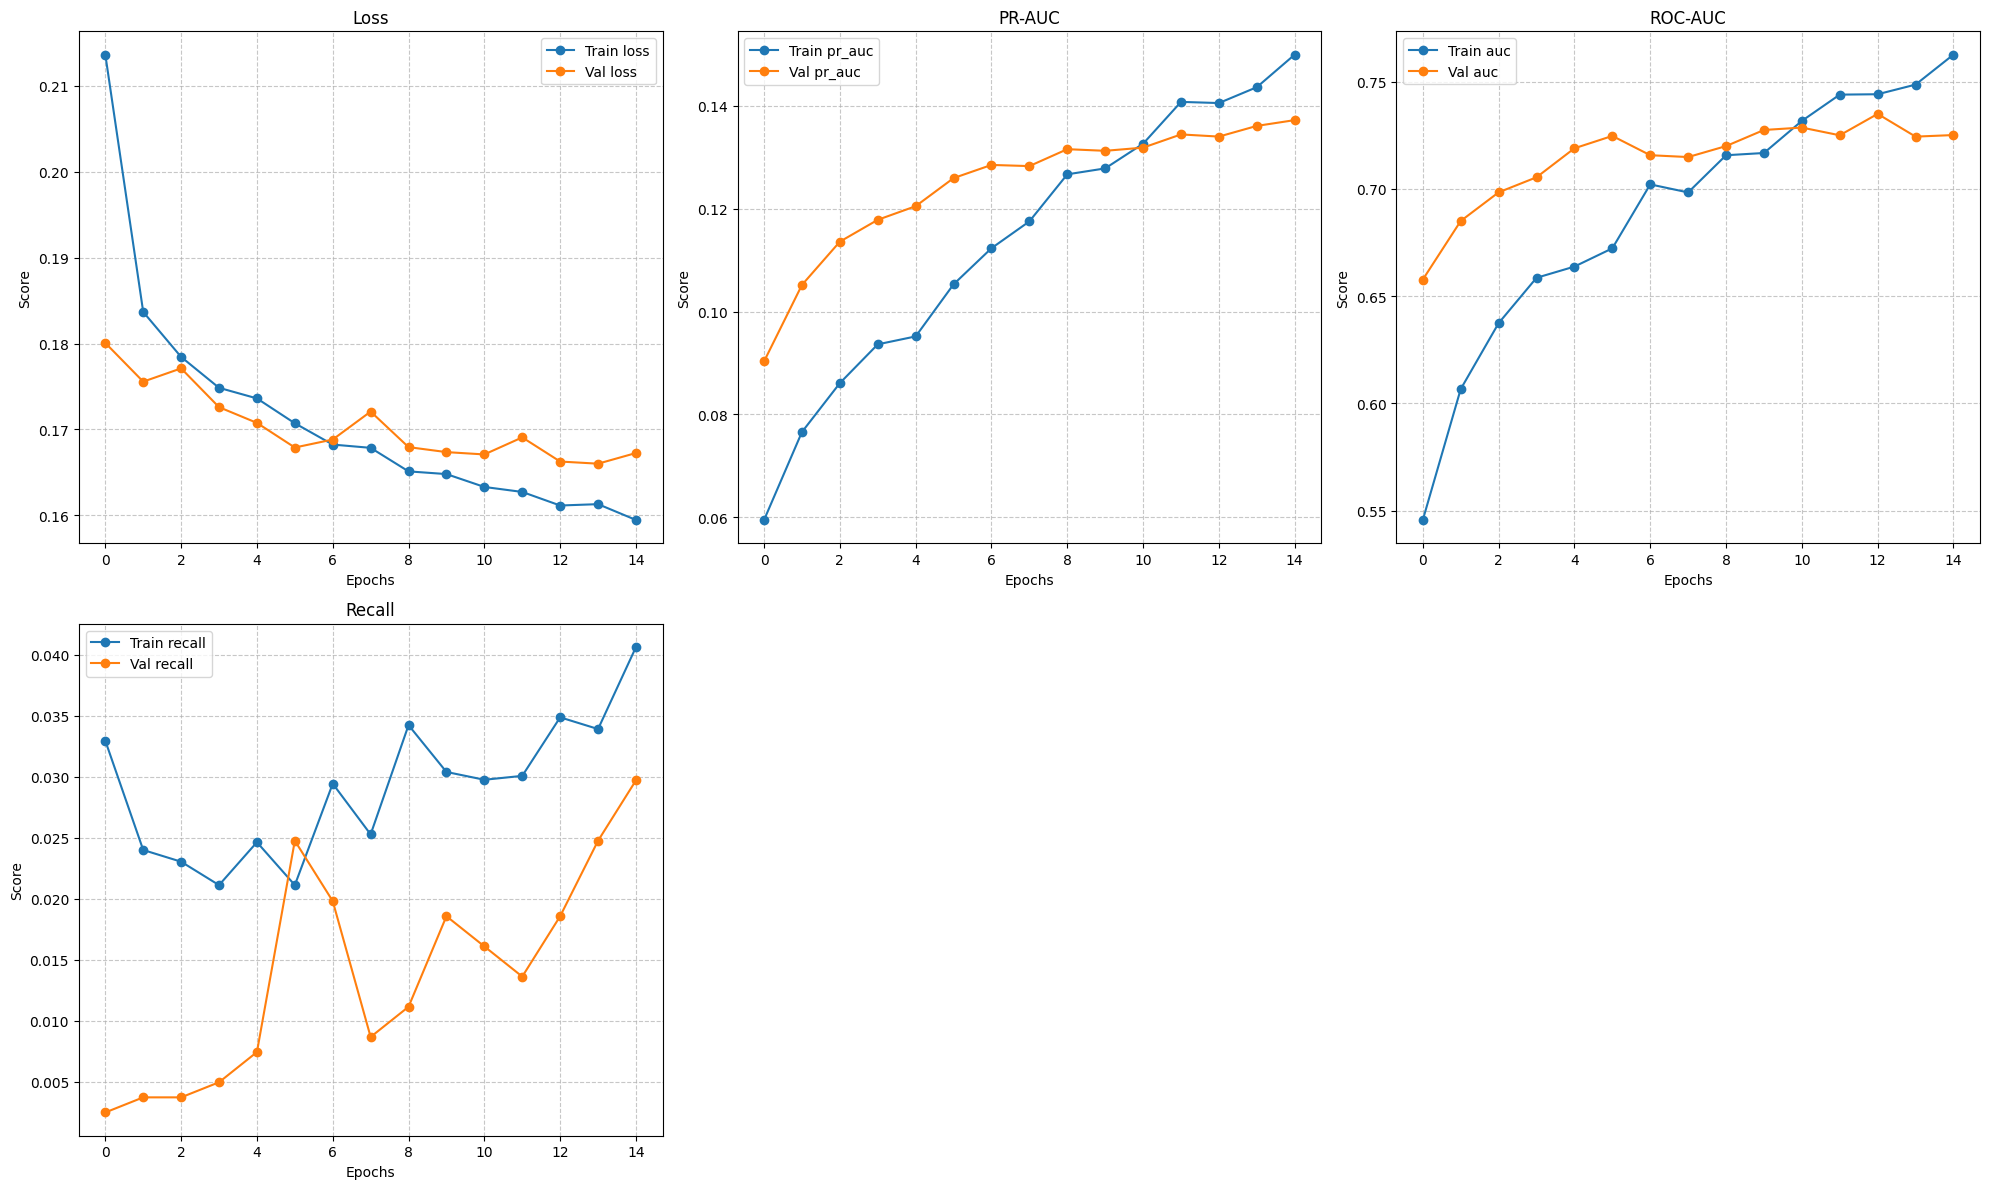

In [32]:
def plot_history(history):
    metrics = ['loss', 'pr_auc', 'auc', 'recall']
    titles  = ['Loss', 'PR-AUC', 'ROC-AUC', 'Recall']

    plt.figure(figsize=(20, 12))

    for i, metric in enumerate(metrics):
        if metric in history.history:
            plt.subplot(2, 3, i+1)
            plt.plot(history.history[metric], label=f'Train {metric}', marker='o')
            plt.plot(history.history[f'val_{metric}'], label=f'Val {metric}', marker='o')
            plt.title(titles[i])
            plt.xlabel('Epochs')
            plt.ylabel('Score')
            plt.legend()
            plt.grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

plot_history(history_best)

In [33]:
print("Generando métricas finales en validación...")
final_results = best_model.evaluate(val_gen, verbose=1)

metrics_dict = {name: val for name, val in zip(best_model.metrics_names, final_results)}

final_df = pd.DataFrame([metrics_dict])
print("\n--- RESULTADOS FINALES DEL MEJOR MODELO ---")
display(final_df.style.background_gradient(axis=1, cmap='Blues'))

Generando métricas finales en validación...
36/36 ━━━━━━━━━━━━━━━━━━━━ 19s 503ms/step - auc: 0.7001 - loss: 0.1546 - pr_auc: 0.1312 - recall: 0.0327

--- RESULTADOS FINALES DEL MEJOR MODELO ---


,loss,compile_metrics
0,0.167260,0.137244


### Ajuste de umbrales

In [34]:
from sklearn.metrics import precision_recall_curve
import numpy as np
import json

y_true_all = []
y_pred_all = []

for i in range(len(val_gen)):
    X_batch, y_batch = val_gen[i]
    pred_batch = best_model.predict(X_batch, verbose=0)

    y_true_all.append(y_batch)
    y_pred_all.append(pred_batch)

y_true_all = np.concatenate(y_true_all)
y_pred_all = np.concatenate(y_pred_all)

BETA = 2.0
optimal_thresholds = {}

print(f"\n--- CALIBRACIÓN DE UMBRALES (Maximizando F{int(BETA)}-Score) ---")
print(f"{'Enfermedad':<20} | {'Umbral':<10} | {'F2-Score':<10} | {'Recall':<10} | {'Precision':<10}")
print("-" * 75)

for i, label in enumerate(LABEL_COLS):
    precision, recall, thresholds = precision_recall_curve(y_true_all[:, i], y_pred_all[:, i])

    # 2. Calcular F-Score para todos los puntos de la curva
    # Fórmula: (1 + B^2) * (P * R) / ((B^2 * P) + R)
    numerator = (1 + BETA**2) * (precision * recall)
    denominator = ((BETA**2 * precision) + recall)

    with np.errstate(divide='ignore', invalid='ignore'):
        f_scores = numerator / denominator
        f_scores = np.nan_to_num(f_scores)

    best_idx = np.argmax(f_scores)

    if best_idx < len(thresholds):
        best_thresh = thresholds[best_idx]
    else:
        best_thresh = thresholds[-1]

    best_fscore = f_scores[best_idx]
    act_recall = recall[best_idx]
    act_precision = precision[best_idx]

    optimal_thresholds[label] = float(best_thresh)

    print(f"{label:<20} | {best_thresh:.4f}     | {best_fscore:.4f}     | {act_recall:.4f}     | {act_precision:.4f}")

with open('optimal_thresholds.json', 'w') as f:
    json.dump(optimal_thresholds, f)

print("\nUmbrales optimizados (F2) guardados en 'optimal_thresholds.json'")


--- CALIBRACIÓN DE UMBRALES (Maximizando F2-Score) ---
Enfermedad           | Umbral     | F2-Score   | Recall     | Precision 
---------------------------------------------------------------------------
Atelectasis          | 0.1063     | 0.4341     | 0.5455     | 0.2389
Cardiomegaly         | 0.0485     | 0.2826     | 0.3714     | 0.1444
Consolidation        | 0.0364     | 0.3300     | 0.7021     | 0.1058
Edema                | 0.0480     | 0.2670     | 0.5789     | 0.0846
Effusion             | 0.0629     | 0.5628     | 0.8358     | 0.2440
Emphysema            | 0.0370     | 0.2647     | 0.5000     | 0.0918
Fibrosis             | 0.0143     | 0.2000     | 0.4286     | 0.0638
Hernia               | 0.0026     | 0.0645     | 0.6667     | 0.0140
Infiltration         | 0.0822     | 0.5434     | 0.9279     | 0.2044
Mass                 | 0.0307     | 0.3160     | 0.6610     | 0.1024
Nodule               | 0.0487     | 0.3077     | 0.6061     | 0.1036
Pleural_Thickening   | 0.0206     | 

## Descargar

In [35]:
import joblib
import json

# 1. Guardar el modelo de Keras
model_filename = 'chest_xray_best_model.keras'
best_model.save(model_filename)
print(f"Modelo guardado como: {model_filename}")

# 2. Guardar el MultiLabelBinarizer (para traducir de 0/1 a nombres de enfermedades)
mlb_filename = 'multilabel_binarizer.joblib'
joblib.dump(mlb, mlb_filename)
print(f"Binarizer guardado como: {mlb_filename}")

# 3. Guardar el StandardScaler (para normalizar la edad del paciente nuevo igual que en el training)
scaler_filename = 'age_scaler.joblib'
joblib.dump(scaler, scaler_filename)
print(f"Scaler guardado como: {scaler_filename}")

# 4. Guardar la lista de etiquetas en orden (Metadata útil)
labels_filename = 'class_names.json'
with open(labels_filename, 'w') as f:
    json.dump(LABEL_COLS, f)
print(f"Etiquetas guardadas en: {labels_filename}")

Modelo guardado como: chest_xray_best_model.keras
Binarizer guardado como: multilabel_binarizer.joblib
Scaler guardado como: age_scaler.joblib
Etiquetas guardadas en: class_names.json


In [36]:
from google.colab import files

# Nombre del archivo comprimido
zip_filename = 'inference_artifacts.zip'

# Comprimir los archivos generados
!zip -r {zip_filename} chest_xray_best_model.keras multilabel_binarizer.joblib age_scaler.joblib class_names.json optimal_thresholds.json

# Descargar
print(f"Descargando {zip_filename}...")
files.download(zip_filename)

  adding: chest_xray_best_model.keras (deflated 8%)
  adding: multilabel_binarizer.joblib (deflated 35%)
  adding: age_scaler.joblib (deflated 29%)
  adding: class_names.json (deflated 33%)
  adding: optimal_thresholds.json (deflated 39%)
Descargando inference_artifacts.zip...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>